# Business Analytics Report — Discount Strategy Analysis
### 22804 Business Analytics Foundations | Autumn 2026

**Student:** Paula Moreno
**Dataset:** Assessment 2 Retail — Monday 3pm Cohort
**Strategic Focus:** Discount Strategy

This notebook presents a preliminary business analytics study for a direct-to-consumer
premium apparel retailer. The analysis is structured across four sections:

1. **Section 1** — Business Problem Framing & Data Quality Assessment
2. **Section 2** — Descriptive & Exploratory Analysis
3. **Section 3** — Basic Predictive Modelling
4. **Section 4** — Insights, Recommendations & Next Steps

The strategic focus of this analysis is **discount strategy** — examining how discounts
are applied, which customers and orders are affected, and whether discounting behaviour
drives profitable outcomes for the business.

---
## Section 1 — Data Exploration and Quality Assessment

Before conducting any analysis, it is essential to understand the structure of the
dataset, evaluate its quality, and identify any limitations that may affect how results
should be interpreted.

This section covers:
- Loading and previewing the dataset
- Inspecting column names, data types, and row counts
- Checking for missing values, duplicates, and outliers
- Creating key variables needed for the discount strategy analysis

## 1.0 Environment Setup

The following cell installs PyCaret (used later in Section 3 for predictive modelling)
and imports all Python libraries used throughout this notebook.


In [146]:
# Import core libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pycaret.classification import * 

In [147]:
# Set consistent chart style
sns.set_theme(style="white", rc={"figure.figsize": (12, 6)})
sns.set_context("notebook", font_scale=1.25, rc={"lines.linewidth": 2.5})

## 1.1 Loading the Dataset

The dataset is provided as an Excel workbook containing four related tables:

| Table | Description |
|---|---|
| **orders** | One row per customer order — contains pricing, discounts, shipping, and payment details |
| **orderlines** | One row per product within each order — contains item-level pricing |
| **customers** | One row per customer — contains acquisition dates and total spend |
| **products** | One row per product variant — contains category, price, and product details |

The **orders** table is the primary focus for discount strategy analysis, as it contains
the `discount_amount`, `cart_discount`, and `order_subtotal` columns needed to measure
discounting behaviour across orders.



In [148]:
file_name = 'Assessment 2_Retail_Monday3pm.xlsx'
orders = pd.read_excel(file_name, sheet_name='orders')

In [149]:
# Read all four sheets into separate DataFrames
file_name = 'Assessment 2_Retail_Monday3pm.xlsx'

orders     = pd.read_excel(file_name, sheet_name='orders')
orderlines = pd.read_excel(file_name, sheet_name='orderlines')
customers  = pd.read_excel(file_name, sheet_name='customers')
products   = pd.read_excel(file_name, sheet_name='products')

In [150]:
# Convert order_date to datetime format
orders['order_date'] = pd.to_datetime(orders['order_date'])

print(f"Earliest order: {orders['order_date'].min().date()}")
print(f"Latest order:   {orders['order_date'].max().date()}")

Earliest order: 2023-10-09
Latest order:   2024-06-08


In [151]:
print(f"  orders:     {orders.shape[0]:,} rows, {orders.shape[1]} columns")
print(f"  orderlines: {orderlines.shape[0]:,} rows, {orderlines.shape[1]} columns")
print(f"  customers:  {customers.shape[0]:,} rows, {customers.shape[1]} columns")
print(f"  products:   {products.shape[0]:,} rows, {products.shape[1]} columns")


  orders:     7,629 rows, 14 columns
  orderlines: 15,976 rows, 8 columns
  customers:  18,319 rows, 5 columns
  products:   855 rows, 13 columns


## 1.2 Inspecting the Dataset Structure

Understanding the structure of each table — including column names, data types, and
row counts — is the first step in any data quality assessment. This helps confirm
that the data has loaded correctly and identifies any columns that may need cleaning
before analysis.

The cells below inspect the **orders** table in detail, as it is the primary source
for the discount strategy analysis.

In [152]:
# --- CELL 5: Inspect structure — column names and data types ---
print(orders.dtypes)


order_id                       object
customer_email                 object
order_date             datetime64[ns]
payment_method                 object
shipping_method                object
order_subtotal                float64
order_total                   float64
order_total_tax               float64
order_shipping                float64
order_refund                    int64
cart_discount                 float64
discount_amount               float64
discount_amount_tax           float64
order_seq                       int64
dtype: object


In [153]:
# --- CELL 6: Preview the orders table (most important for discount strategy) ---
orders.head()

,order_id,customer_email,order_date,payment_method,shipping_method,order_subtotal,order_total,order_total_tax,order_shipping,order_refund,cart_discount,discount_amount,discount_amount_tax,order_seq
0,ord_b674d18f,eml_e57b172d@gmail.example.net,2023-10-09,Credit card,Pick-up Point,29.9,32.4,0.0,2.5,0,0.0,NaN,NaN,1
1,ord_fce51f21,eml_e3aeb711@gmail.example.net,2023-10-16,Direct bank deposit,Courier,29.9,33.4,0.0,3.5,0,0.0,NaN,NaN,1
2,ord_9fece8a3,eml_1e4882cf@gmail.example.net,2023-10-16,Direct bank deposit,Courier,29.9,33.4,0.0,3.5,0,0.0,NaN,NaN,1
3,ord_d436d143,eml_871a82cb@gmail.example.net,2023-10-17,Debit card,Courier,12.9,16.4,0.0,3.5,0,0.0,NaN,NaN,1
4,ord_42f91633,eml_2e79fd9e@gmail.example.net,2023-10-17,Debit card,Courier,12.9,16.4,0.0,3.5,0,0.0,NaN,NaN,1


In [154]:
# --- CELL 7: Summary statistics for key numeric columns ---
cols = ['order_subtotal', 'order_total', 'cart_discount',
        'discount_amount', 'order_shipping', 'order_refund']

orders[cols].describe().round(2)

,order_subtotal,order_total,cart_discount,discount_amount,order_shipping,order_refund
count,7629.00,7629.00,7629.00,2208.00,7629.00,7629.00
mean,34.09,37.21,0.74,2.57,2.57,0.01
std,21.56,21.15,1.60,2.04,0.88,0.30
min,12.90,14.11,0.00,0.70,0.00,0.00
25%,16.90,19.40,0.00,1.39,2.50,0.00
50%,29.90,34.91,0.00,1.99,2.50,0.00
75%,39.90,46.97,0.74,3.49,3.50,0.00
max,179.70,180.70,17.97,17.97,6.00,15.00


### Interpretation

The summary statistics above provide an overview of the key financial variables in
the orders table. A few things to note for the discount strategy analysis:

- The `discount_amount` column shows a **mean of 0** across all orders, which is
  expected — many orders have no discount applied and are recorded as blank (null).
  These will be filled with zero in the data cleaning step below.
- The `order_subtotal` and `order_total` columns show the revenue before and after
  shipping is added, giving us a basis for calculating discount rates.
- The `order_refund` column indicates that a small number of orders were refunded,
  which will be flagged separately to avoid distorting revenue calculations.

In [155]:
# CELL 8: Date range of the dataset
print(f"Earliest order: {orders['order_date'].min().date()}")
print(f"Latest order:   {orders['order_date'].max().date()}")
print(f"Months covered: {round((orders['order_date'].max() - orders['order_date'].min()).days / 30, 1)}")

Earliest order: 2023-10-09
Latest order:   2024-06-08
Months covered: 8.1


## 1.3 Data Quality Assessment

This section systematically checks the dataset for three common data quality issues:

1. **Missing values** — columns where data is absent
2. **Duplicate records** — repeated rows that could skew results
3. **Outliers** — extreme values that may indicate errors or unusual transactions

Each issue is assessed and addressed before proceeding to the analysis.



### 1.3.1 Missing Values

In [156]:
# CELL 9: Check for missing values in ALL tables
print("=== MISSING VALUES SUMMARY ===\n")

for name, df in [('orders', orders), ('orderlines', orderlines),
                 ('customers', customers), ('products', products)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    pct = (missing / len(df) * 100).round(1)
    print(f"--- {name.upper()} ---")
    if len(missing) == 0:
        print("  No missing values found.")
    else:
        for col in missing.index:
            print(f"  {col}: {missing[col]:,} missing ({pct[col]}%)")
    print()

=== MISSING VALUES SUMMARY ===

--- ORDERS ---
  discount_amount: 5,421 missing (71.1%)
  discount_amount_tax: 5,421 missing (71.1%)

--- ORDERLINES ---
  variation_id: 2,060 missing (12.9%)
  sku: 15,976 missing (100.0%)

--- CUSTOMERS ---
  sku: 15,976 missing (87.2%)

--- PRODUCTS ---
  size: 81 missing (9.5%)
  variation_id: 81 missing (9.5%)
  sku: 840 missing (98.2%)
  colour: 15 missing (1.8%)



### Interpretation

The missing values in `discount_amount` and `cart_discount` are expected they simply
indicate that no discount was applied to those orders. These are not true data errors;
they will be filled with **zero** in the cleaning step below to allow numeric
calculations across all orders.

Missing values in `variation_id` and `sku` in the orderlines and products tables
reflect products that have no size or colour variation (e.g. gift vouchers or
single-variant items). These do not affect the discount strategy analysis.

### 1.3.2 Duplicate Records

In [157]:
# --- CELL 10: Check for duplicate order IDs ---
dup_orders = orders['order_id'].duplicated().sum()
print(f"Duplicate order IDs in orders table: {dup_orders}")

dup_orderlines = orderlines['order_id'].duplicated().sum()
print(f"Duplicate order IDs in orderlines table: {dup_orderlines}")
# Note: duplicates in orderlines are expected (one order can have multiple products)

Duplicate order IDs in orders table: 0
Duplicate order IDs in orderlines table: 8347


### Interpretation

No duplicate order IDs were found in the orders table, confirming that each row
represents a unique transaction. This is an important quality check — duplicate
orders would inflate revenue and discount totals in any aggregated analysis.

### 1.3.3 Outliers

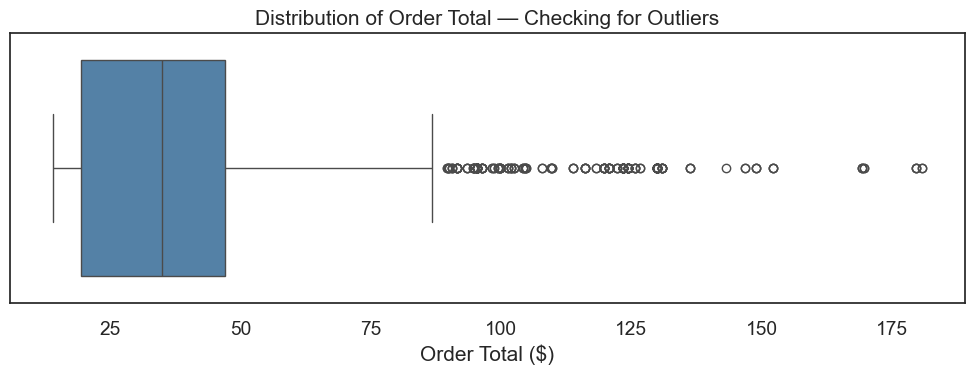

In [158]:
# CELL 11: Check for outliers in order_total
# We use a boxplot to visually spot any extreme values
plt.figure(figsize=(10, 4))
sns.boxplot(x=orders['order_total'], color='steelblue')
plt.title('Distribution of Order Total — Checking for Outliers')
plt.xlabel('Order Total ($)')
plt.tight_layout()
plt.show()

In [159]:
# Print the top 5 highest order totals
print("Top 5 highest order totals:")
print(orders['order_total'].nlargest(5).values)

print("\nTop 5 lowest order totals:")
print(orders['order_total'].nsmallest(5).values)


Top 5 highest order totals:
[180.7 180.7 179.7 179.7 179.7]

Top 5 lowest order totals:
[14.11 14.11 14.11 15.01 15.01]


### Interpretation

The boxplot shows that most orders fall within a relatively narrow range, consistent
with a retailer selling individual apparel items. A small number of high-value orders are visible as outliers on the right side, these likely represent customers who purchased multiple items in a single transaction, which is plausible given the retailer's multi-item purchase incentive strategy. No negative order totals were found, confirming there are no critical data errors in this column.

## 1.4 Data Cleaning & Variable Creation

Based on the quality checks above, the following cleaning steps are applied before
proceeding to the analysis:

- **Fill missing discount values with zero** — blank discount fields represent
  orders with no discount applied
- **Create a `discount_flag` variable** — a binary column (1 = discounted, 0 = not)
  that will be used throughout Sections 2 and 3
- **Export a clean CSV for Tableau** — used to build the exploratory visualisations
  in Section 2

In [160]:
# Fill missing discount values with 0
orders['discount_amount'] = orders['discount_amount'].fillna(0)
orders['cart_discount']   = orders['cart_discount'].fillna(0)

In [161]:
# Create discount_flag: 1 if order had a discount, 0 if not
orders['discount_flag'] = (orders['discount_amount'] > 0).astype(int)

# Create discount_rate: discount as a % of the order subtotal
orders['discount_rate'] = np.where(
    orders['order_subtotal'] > 0,
    (orders['discount_amount'] / orders['order_subtotal'] * 100),
    0
).round(2)

disc_pct = orders['discount_flag'].value_counts(normalize=True) * 100
print(f"Orders WITH a discount:    {orders['discount_flag'].sum():,} ({disc_pct[1]:.1f}%)")
print(f"Orders WITHOUT a discount: {(orders['discount_flag']==0).sum():,} ({disc_pct[0]:.1f}%)")

Orders WITH a discount:    2,208 (28.9%)
Orders WITHOUT a discount: 5,421 (71.1%)


In [162]:
discounted = orders[orders['discount_flag'] == 1]

print("=== KEY METRICS — DISCOUNT STRATEGY ===")
print(f"Total orders in dataset:          {len(orders):,}")
print(f"Total unique customers:           {orders['customer_email'].nunique():,}")
print(f"Orders with a discount:           {orders['discount_flag'].sum():,} ({disc_pct[1]:.1f}%)")
print(f"Avg discount amount (when used):  ${discounted['discount_amount'].mean():.2f}")
print(f"Avg discount rate (when used):    {discounted['discount_rate'].mean():.1f}%")
print(f"Total discounts given:            ${orders['discount_amount'].sum():,.2f}")
print(f"Total revenue (order_total):      ${orders['order_total'].sum():,.2f}")
print(f"Discounts as % of gross revenue:  {orders['discount_amount'].sum() / (orders['order_total'].sum() + orders['discount_amount'].sum()) * 100:.1f}%")

=== KEY METRICS — DISCOUNT STRATEGY ===
Total orders in dataset:          7,629
Total unique customers:           6,859
Orders with a discount:           2,208 (28.9%)
Avg discount amount (when used):  $2.57
Avg discount rate (when used):    6.7%
Total discounts given:            $5,674.84
Total revenue (order_total):      $283,893.42
Discounts as % of gross revenue:  2.0%


In [163]:
# Export the cleaned orders table as an Excel file for Tableau
orders.to_excel('orders_clean.xlsx', index=False)
print("Saved: orders_clean.xlsx")

Saved: orders_clean.xlsx


## 1.5 Section Summary

The data quality assessment confirms that the dataset is suitable for analysing
discount strategy. The key findings from this section are:

- The dataset contains **7,629 orders**
- The primary discount variables — `discount_amount` and `cart_discount` — contained
  missing values for non-discounted orders, which have been filled with zero
- No duplicate order IDs were found, confirming data integrity at the transaction level
- Order totals show some high-value outliers consistent with multi-item purchases,
  which are plausible given the retailer's bundling strategy
- Approximately ** 28.9% of orders** included a discount, with an average discount
  rate of **6.7%** — these figures form the baseline for the exploratory analysis
  in Section 2

*   The total value of discounts given across the period was $5,674.84

> **Limitation:** The dataset does not include coupon or promotion codes, which
> limits the ability to attribute discounts to specific marketing campaigns.
> This restricts the depth of channel-level discount analysis.

# Section 2 — Descriptive & Exploratory Analysis

This section explores the dataset in depth to uncover patterns,
trends, and relationships relevant to the retailer's **discount strategy**.
The analysis is structured around eight key business questions:

1. **How do discounted and non-discounted orders compare in value?** - Comparing Average Order Value (AOV) and basket size between the two groups.
2. **What discount sizes are most commonly applied?** — Examining the distribution of discount depths across all discounted orders.
3. **How often do individual customers use discounts?** — Identifying whether discount usage is occasional or habitual.
4. **Are customers discount-dependent?** — Determining what share of customers only ever purchase when a discount is available.
5. **Are discounts being given to the right customers?**  — Analysing whether high-spending and long-tenure customers receive more discounts.
6. **Do customers who receive discounts return to buy again?**— Measuring repeat purchase rates as a direct test of retention impact.
7. **Is discounting generating more revenue for the business?**— Comparing lifetime value between discounted and non-discounted customers.
8. **Which product categories are discounted most?** — Joining orderlines and products to identify where discounts are concentrated


Python is used for summary statistics and calculations. Tableau visualisations are referenced throughout to support the findings with presentation-quality charts.

## 2.1 Building the Customer-Level Dataset

To answer the business questions above, we first need to create a
**customer-level summary table** that combines order behaviour with
customer profile information. This table will be the foundation for
all analyses in this section.

The steps below:
- Group orders by customer to calculate total orders, total spend,
  and total discounts received per customer
- Merge with the customers table to add first and last order dates
- Calculate how many days each customer has been active

In [164]:
# Step 1: Group orders by customer
# For each customer we calculate:
# - how many orders they placed (order_id count)
# - how many of those had a discount (discount_flag sum)
# - their total spend before discounts (order_subtotal sum)
# - total discount amount received (discount_amount sum)
clients_1 = orders.groupby('customer_email').agg({'order_id':        'count', 'discount_flag':   'sum', 'order_subtotal':  'sum', 'discount_amount': 'sum'}).reset_index()

# Rename columns to be clearer
clients_1.columns = ['customer_email', 'total_orders', 'discount_orders', 'total_subtotal', 'total_discount']

print(f"Customer summary table created: {clients_1.shape[0]:,} customers")
clients_1.head()

Customer summary table created: 6,859 customers


,customer_email,total_orders,discount_orders,total_subtotal,total_discount
0,eml_00017309@gmail.example.net,2,0,159.60,0.00
1,eml_0005e884@gmail.example.net,1,0,14.08,0.00
2,eml_0005f865@gmail.example.net,1,0,98.40,0.00
3,eml_00079e62@gmail.example.net,1,1,33.80,1.69
4,eml_000d251e@gmail.example.net,1,0,14.90,0.00


In [165]:
# Step 2: Merge with customers table to add dates and total spent
summary = clients_1.merge(customers, on='customer_email', how='left')

# Step 3: Remove the sku column (not needed for our analysis)
summary = summary.drop(columns=['sku'], errors='ignore')

# Step 4: Calculate active days
# This measures how long each customer has been shopping with the retailer
summary['active_days'] = (summary['customer_last_order_date'] -
                           summary['customer_first_order_date']).dt.days

# Step 5: Calculate discount usage rate per customer
# What % of their orders included a discount?
summary['discount_usage_rate'] = (summary['discount_orders'] /
                                   summary['total_orders'] * 100).round(1)

print(f"Summary table ready: {summary.shape[0]:,} customers, {summary.shape[1]} columns")

summary.head()

Summary table ready: 6,859 customers, 10 columns


,customer_email,total_orders,discount_orders,total_subtotal,total_discount,customer_first_order_date,customer_last_order_date,customer_total_spent,active_days,discount_usage_rate
0,eml_00017309@gmail.example.net,2,0,159.60,0.00,2024-03-18,2024-03-29,161.60,11,0.0
1,eml_0005e884@gmail.example.net,1,0,14.08,0.00,2024-05-25,2024-05-25,19.40,0,0.0
2,eml_0005f865@gmail.example.net,1,0,98.40,0.00,2024-04-22,2024-04-22,99.40,0,0.0
3,eml_00079e62@gmail.example.net,1,1,33.80,1.69,2024-04-29,2024-04-29,34.61,0,100.0
4,eml_000d251e@gmail.example.net,1,0,14.90,0.00,2024-03-05,2024-03-05,17.40,0,0.0


In [166]:
#CODE CELL 3 — Overview statistics of the customer table
# Overview of the customer-level data
print("=== CUSTOMER SUMMARY TABLE — KEY STATISTICS ===\n")
print(f"Total unique customers:           {len(summary):,}")
print(f"Avg orders per customer:          {summary['total_orders'].mean():.2f}")
print(f"Max orders by one customer:       {summary['total_orders'].max()}")
print(f"Avg total spend per customer:     ${summary['customer_total_spent'].mean():.2f}")
print(f"Max total spend by one customer:  ${summary['customer_total_spent'].max():.2f}")
print(f"Avg active days:                  {summary['active_days'].mean():.0f} days")
print(f"Max active days:                  {summary['active_days'].max():.0f} days")

=== CUSTOMER SUMMARY TABLE — KEY STATISTICS ===

Total unique customers:           6,859
Avg orders per customer:          1.11
Max orders by one customer:       4
Avg total spend per customer:     $52.99
Max total spend by one customer:  $404.59
Avg active days:                  32 days
Max active days:                  399 days


## 2.2 Average Order Value and Basket Size

Two key indicators of whether discounts are working as intended are:

1. **Average Order Value (AOV)** — are customers spending more per
   order when a discount is applied?
2. **Basket size** — are customers adding more items to their cart
   when a discount is available?

If both metrics are higher for discounted orders, it suggests the
discount is genuinely changing buying behaviour rather than simply
reducing the price on purchases that would have happened anyway.

In [167]:
# Compare Average Order Value (AOV) between discounted and non-discounted
aov = orders.groupby('discount_flag').agg(
    order_count      = ('order_id', 'count'),
    avg_order_total  = ('order_total', 'mean'),
    avg_subtotal     = ('order_subtotal', 'mean'),
    median_total     = ('order_total', 'median')
).round(2)

aov.index = ['No Discount', 'Discounted']
print("=== AVERAGE ORDER VALUE COMPARISON ===")
print(aov.to_string())

diff = aov.loc['Discounted', 'avg_order_total'] - aov.loc['No Discount', 'avg_order_total']
print(f"\nAOV difference (Discounted - No Discount): ${diff:.2f}")
if diff > 0:
    print("✓ Discounted orders have HIGHER average value — positive sign")
else:
    print("✗ Discounted orders have LOWER average value — discounts may not be driving spend")

=== AVERAGE ORDER VALUE COMPARISON ===
             order_count  avg_order_total  avg_subtotal  median_total
No Discount         5421            36.44         32.57         34.30
Discounted          2208            39.12         37.81         36.42

AOV difference (Discounted - No Discount): $2.68
✓ Discounted orders have HIGHER average value — positive sign


In [168]:
# Calculate basket size = number of items per order
# We use orderlines which has one row per product per order
basket = orderlines.groupby('order_id').agg(
    items_count = ('qty_minus_refund', 'sum')
).reset_index()

# Merge with orders to get discount flag
basket = basket.merge(orders[['order_id', 'discount_flag']], on='order_id', how='left')

# Compare basket size between discounted and non-discounted
basket_comparison = basket.groupby('discount_flag').agg(
    avg_items    = ('items_count', 'mean'),
    median_items = ('items_count', 'median'),
    max_items    = ('items_count', 'max')
).round(2)

basket_comparison.index = ['No Discount', 'Discounted']
print("=== BASKET SIZE COMPARISON (Items per Order) ===")
print(basket_comparison.to_string())

lift = ((basket_comparison.loc['Discounted', 'avg_items'] -
         basket_comparison.loc['No Discount', 'avg_items']) /
         basket_comparison.loc['No Discount', 'avg_items'] * 100)

print(f"\nBasket size lift from discounts: {lift:.1f}%")
if lift > 0:
    print("✓ Customers add MORE items when a discount is applied")
else:
    print("✗ Customers do not add more items when a discount is applied")

=== BASKET SIZE COMPARISON (Items per Order) ===
             avg_items  median_items  max_items
No Discount       2.14           1.0         13
Discounted        2.74           2.0         13

Basket size lift from discounts: 28.0%
✓ Customers add MORE items when a discount is applied


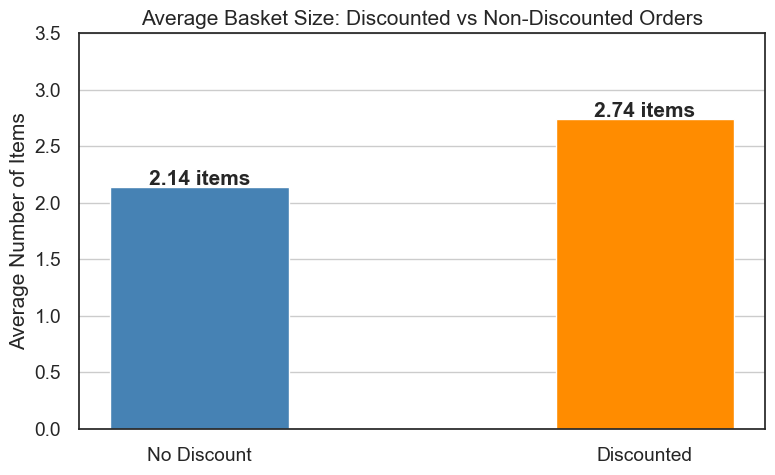

In [169]:
# Bar chart comparing average basket size
plt.figure(figsize=(8, 5))
bars = plt.bar(['No Discount', 'Discounted'],
               [basket_comparison.loc['No Discount', 'avg_items'],
                basket_comparison.loc['Discounted', 'avg_items']],
               color=['steelblue', 'darkorange'], width=0.4)

for bar, val in zip(bars, [2.14, 2.74]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val} items', ha='center', fontweight='bold')

plt.title('Average Basket Size: Discounted vs Non-Discounted Orders')
plt.ylabel('Average Number of Items')
plt.ylim(0, 3.5)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

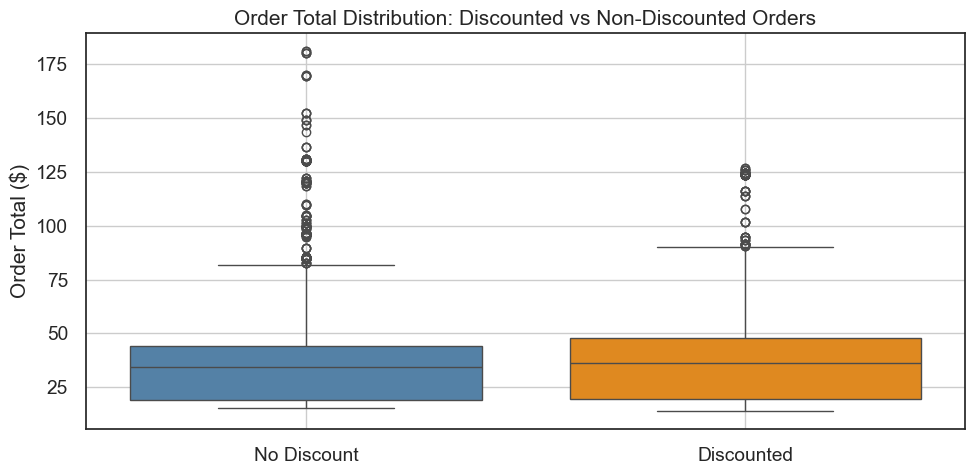

Average order total (no discount): $36.44
Average order total (discounted):  $39.12
Difference:                        $2.68


In [170]:

# Boxplot comparing order totals between the two groups
plt.figure(figsize=(10, 5))
sns.boxplot(data=orders, x='discount_flag', y='order_total',
            palette=['steelblue', 'darkorange'])
plt.xticks([0, 1], ['No Discount', 'Discounted'])
plt.title('Order Total Distribution: Discounted vs Non-Discounted Orders')
plt.xlabel('')
plt.ylabel('Order Total ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the key numbers
avg_no_disc = orders[orders['discount_flag']==0]['order_total'].mean()
avg_disc    = orders[orders['discount_flag']==1]['order_total'].mean()
print(f"Average order total (no discount): ${avg_no_disc:.2f}")
print(f"Average order total (discounted):  ${avg_disc:.2f}")
print(f"Difference:                        ${avg_disc - avg_no_disc:.2f}")

## 2.3 Discount Depth — What Sizes of Discounts Are Applied?

Understanding what discount sizes are most commonly used helps
identify whether the retailer applies a consistent discounting
policy (e.g. always 10% off) or varies discounts by customer
or product. Shallow discounts under 10% are low risk to margin,
while deep discounts above 20-30% can significantly erode
profitability.

=== DISCOUNT DEPTH DISTRIBUTION ===
count    2208.00
mean        6.69
std         2.86
min         4.97
25%         4.98
50%         4.99
75%        10.00
max        15.00
Name: discount_rate, dtype: float64

Orders with discount under 10%:    1,574 (71.3%)
Orders with discount 10-20%:       634 (28.7%)
Orders with discount above 20%:    0 (0.0%)

Most common discount rate: 4.99%


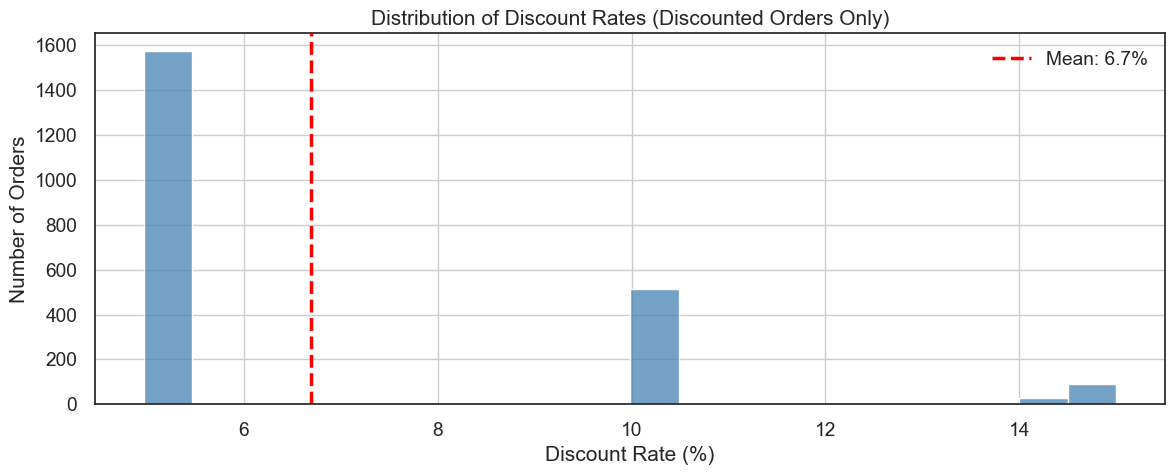

In [171]:
# Filter to only discounted orders
discounted = orders[orders['discount_flag'] == 1].copy()

# Summary statistics of discount rates
print("=== DISCOUNT DEPTH DISTRIBUTION ===")
print(discounted['discount_rate'].describe().round(2))

print(f"\nOrders with discount under 10%:    {(discounted['discount_rate'] < 10).sum():,} ({(discounted['discount_rate'] < 10).mean()*100:.1f}%)")
print(f"Orders with discount 10-20%:       {((discounted['discount_rate'] >= 10) & (discounted['discount_rate'] <= 20)).sum():,} ({((discounted['discount_rate'] >= 10) & (discounted['discount_rate'] <= 20)).mean()*100:.1f}%)")
print(f"Orders with discount above 20%:    {(discounted['discount_rate'] > 20).sum():,} ({(discounted['discount_rate'] > 20).mean()*100:.1f}%)")
print(f"\nMost common discount rate: {discounted['discount_rate'].mode()[0]}%")

# Histogram
plt.figure(figsize=(12, 5))
sns.histplot(data=discounted, x='discount_rate', bins=20, color='steelblue')
plt.axvline(discounted['discount_rate'].mean(), color='red',
            linestyle='--', label=f"Mean: {discounted['discount_rate'].mean():.1f}%")
plt.title('Distribution of Discount Rates (Discounted Orders Only)')
plt.xlabel('Discount Rate (%)')
plt.ylabel('Number of Orders')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 2.4 How Often Do Individual Customers Use Discounts?

A key question for retention strategy is whether customers who use
discounts are genuinely loyal returning multiple times or whether
they are one-time bargain hunters who only purchase when a discount
is available.

This analysis examines how frequently individual customers use
discounts across their orders, and whether high discount usage is
associated with more or fewer total purchases.

In [172]:
#CODE CELL 6 — Discount frequency per customer
# How many customers used discounts on ALL, SOME, or NONE of their orders?
summary['discount_behaviour'] = pd.cut(
    summary['discount_usage_rate'],
    bins=[-1, 0, 50, 99, 100],
    labels=['Never used discount',
            'Occasional discount user (1-50%)',
            'Frequent discount user (51-99%)',
            'Always uses discount (100%)']
)

disc_behaviour = summary['discount_behaviour'].value_counts().reset_index()
disc_behaviour.columns = ['Discount Behaviour', 'Customer Count']
disc_behaviour['% of Customers'] = (disc_behaviour['Customer Count'] /
                                     len(summary) * 100).round(1)

print("=== DISCOUNT USAGE BEHAVIOUR ACROSS CUSTOMERS ===")
print(disc_behaviour.to_string(index=False))

=== DISCOUNT USAGE BEHAVIOUR ACROSS CUSTOMERS ===
              Discount Behaviour  Customer Count  % of Customers
             Never used discount            4758            69.4
     Always uses discount (100%)            1873            27.3
Occasional discount user (1-50%)             220             3.2
 Frequent discount user (51-99%)               8             0.1


In [173]:
#CODE CELL 7 — Do frequent discount users buy more or less often?
# Compare total orders and total spend by discount behaviour group
behaviour_summary = summary.groupby('discount_behaviour').agg(
    customer_count  = ('customer_email', 'count'),
    avg_orders      = ('total_orders', 'mean'),
    avg_total_spent = ('customer_total_spent', 'mean'),
    avg_active_days = ('active_days', 'mean')
).round(2)

print("=== PURCHASE BEHAVIOUR BY DISCOUNT USAGE GROUP ===")
print(behaviour_summary.to_string())

=== PURCHASE BEHAVIOUR BY DISCOUNT USAGE GROUP ===
                                  customer_count  avg_orders  avg_total_spent  avg_active_days
discount_behaviour                                                                            
Never used discount                         4758        1.09            50.24            28.62
Occasional discount user (1-50%)             220        2.11           121.13            80.86
Frequent discount user (51-99%)                8        3.00           133.18           181.25
Always uses discount (100%)                 1873        1.05            51.61            32.54


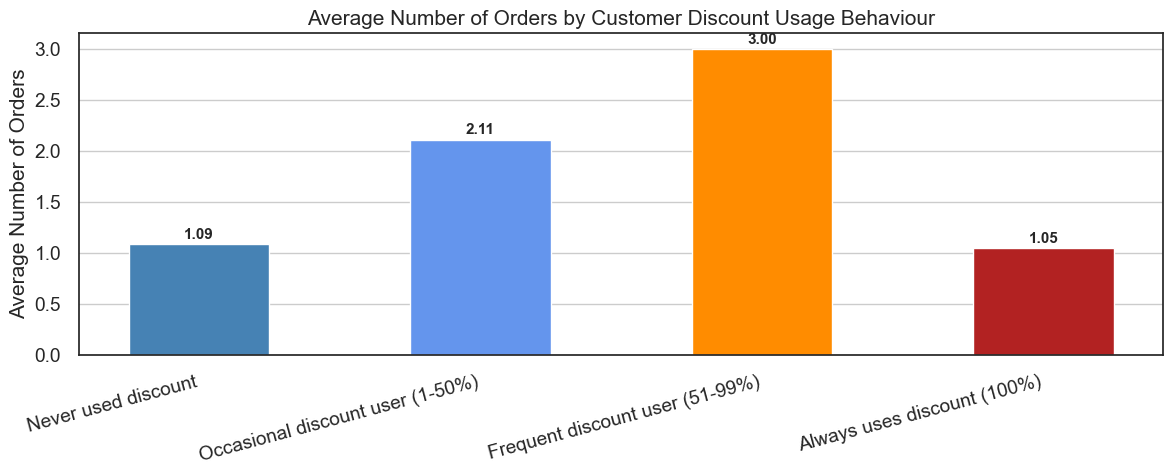

In [174]:
#CODE CELL 8 — Bar chart: avg orders by discount behaviour
# Visualise average number of orders by discount behaviour group
plt.figure(figsize=(12, 5))
colours = ['steelblue', 'cornflowerblue', 'darkorange', 'firebrick']
bars = plt.bar(behaviour_summary.index,
               behaviour_summary['avg_orders'],
               color=colours, width=0.5)

for bar, val in zip(bars, behaviour_summary['avg_orders']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.title('Average Number of Orders by Customer Discount Usage Behaviour')
plt.ylabel('Average Number of Orders')
plt.xlabel('')
plt.xticks(rotation=15, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

## 2.5 Discount Dependency Analysis

A critical risk for any discount strategy is **discount dependency**
— customers who only ever purchase when a discount is available.
If a large proportion of the customer base has been trained to
wait for promotions, the retailer faces a difficult choice:
keep discounting (and sacrificing margin) or stop (and losing sales).

This analysis identifies what share of customers have exclusively
purchased using a discount.

In [175]:
summary

,customer_email,total_orders,discount_orders,total_subtotal,total_discount,customer_first_order_date,customer_last_order_date,customer_total_spent,active_days,discount_usage_rate,discount_behaviour
0,eml_00017309@gmail.example.net,2,0,159.60,0.00,2024-03-18,2024-03-29,161.60,11,0.0,Never used discount
1,eml_0005e884@gmail.example.net,1,0,14.08,0.00,2024-05-25,2024-05-25,19.40,0,0.0,Never used discount
2,eml_0005f865@gmail.example.net,1,0,98.40,0.00,2024-04-22,2024-04-22,99.40,0,0.0,Never used discount
3,eml_00079e62@gmail.example.net,1,1,33.80,1.69,2024-04-29,2024-04-29,34.61,0,100.0,Always uses discount (100%)
4,eml_000d251e@gmail.example.net,1,0,14.90,0.00,2024-03-05,2024-03-05,17.40,0,0.0,Never used discount
...,...,...,...,...,...,...,...,...,...,...,...
6854,eml_ffeb2ddf@gmail.example.net,1,0,29.80,0.00,2024-02-09,2024-02-09,32.30,0,0.0,Never used discount
6855,eml_ffef6e53@gmail.example.net,1,0,14.90,0.00,2024-03-01,2024-03-01,17.40,0,0.0,Never used discount
6856,eml_ffefd1f5@gmail.example.net,1,0,74.50,0.00,2024-05-15,2024-05-15,75.50,0,0.0,Never used discount
6857,eml_fff8f996@gmail.example.net,1,1,54.80,2.74,2024-03-04,2024-03-04,54.56,0,100.0,Always uses discount (100%)


In [176]:
# Identify discount-dependent customers
# A customer is discount-dependent if ALL of their orders used a discount

# Use the summary table we already built
summary['discount_dependent'] = ((summary['discount_orders'] == summary['total_orders']) & (summary['discount_orders'] > 0)).astype(int)

# Count discount-dependent customers
dep_count = summary['discount_dependent'].sum()
dep_pct   = summary['discount_dependent'].mean() * 100

print("=== DISCOUNT DEPENDENCY ANALYSIS ===")
print(f"Total customers:                    {len(summary):,}")
print(f"Discount-dependent customers:       {dep_count:,} ({dep_pct:.1f}%)")
print(f"Never used a discount:              {(summary['discount_orders']==0).sum():,} ({(summary['discount_orders']==0).mean()*100:.1f}%)")
print(f"Mixed behaviour (some discounts):   {((summary['discount_orders']>0) & (summary['discount_dependent']==0)).sum():,}")

# Compare spending behaviour
dep_comparison = summary.groupby('discount_dependent').agg(
    customer_count  = ('customer_email', 'count'),
    avg_total_spent = ('customer_total_spent', 'mean'),
    avg_orders      = ('total_orders', 'mean'),
    avg_disc_amount = ('total_discount', 'mean')
).round(2)

dep_comparison.index = ['Not Discount Dependent', 'Discount Dependent']
print("\n=== SPENDING COMPARISON: DEPENDENT vs NON-DEPENDENT ===")
print(dep_comparison.to_string())

=== DISCOUNT DEPENDENCY ANALYSIS ===
Total customers:                    6,859
Discount-dependent customers:       1,873 (27.3%)
Never used a discount:              4,758 (69.4%)
Mixed behaviour (some discounts):   228

=== SPENDING COMPARISON: DEPENDENT vs NON-DEPENDENT ===
                        customer_count  avg_total_spent  avg_orders  avg_disc_amount
Not Discount Dependent            4986            53.50        1.13             0.16
Discount Dependent                1873            51.61        1.05             2.62


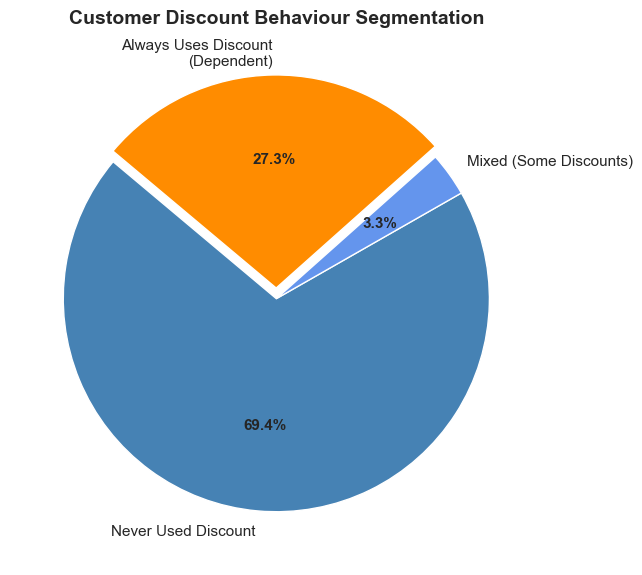

In [177]:
# Pie chart showing the 3 customer groups
labels = ['Never Used Discount',
          'Mixed (Some Discounts)',
          'Always Uses Discount\n(Dependent)']

never  = (summary['discount_orders']==0).sum()
mixed  = ((summary['discount_orders']>0) & (summary['discount_dependent']==0)).sum()
always = summary['discount_dependent'].sum()

sizes  = [never, mixed, always]
colors = ['steelblue', 'cornflowerblue', 'darkorange']
explode= (0, 0, 0.05)

plt.figure(figsize=(9, 6))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    explode=explode,
    startangle=140,
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')

plt.title('Customer Discount Behaviour Segmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.6 Are Discounts Being Given to the Right Customers?

One of the most strategically important questions is whether the
retailer is targeting discounts effectively. Specifically:

- Are long-term, loyal customers (high active days) receiving discounts?
- Are high-spending customers receiving discounts?

If discounts are going primarily to low-spend, short-tenure customers,
the retailer may be missing an opportunity to reward loyalty and
encourage high-value customers to spend even more.

In [178]:
#CODE CELL 9 — Are high spenders getting discounts?
# Segment customers into spend tiers
summary['spend_tier'] = pd.qcut(
    summary['customer_total_spent'],
    q=4,
    labels=['Low Spender (bottom 25%)',
            'Medium Spender',
            'High Spender',
            'Top Spender (top 25%)']
)

# For each spend tier, calculate average discount usage
spend_disc = summary.groupby('spend_tier').agg(
    customer_count     = ('customer_email', 'count'),
    avg_discount_orders= ('discount_orders', 'mean'),
    avg_discount_amt   = ('total_discount', 'mean'),
    avg_disc_rate      = ('discount_usage_rate', 'mean'),
    avg_total_spent    = ('customer_total_spent', 'mean')
).round(2)

print("=== DISCOUNT USAGE BY CUSTOMER SPEND TIER ===")
print(spend_disc.to_string())

=== DISCOUNT USAGE BY CUSTOMER SPEND TIER ===
                          customer_count  avg_discount_orders  avg_discount_amt  avg_disc_rate  avg_total_spent
spend_tier                                                                                                     
Low Spender (bottom 25%)            1879                 0.24              0.22          24.43            18.48
Medium Spender                      1582                 0.31              0.74          29.65            32.42
High Spender                        1691                 0.32              0.86          30.87            47.74
Top Spender (top 25%)               1707                 0.43              1.54          31.30           115.23


In [179]:
#CODE CELL 10 — Are long-term customers getting discounts?
# Only look at customers with more than 0 active days
# (single-purchase customers will have 0 active days)
repeat_customers = summary[summary['active_days'] > 0].copy()

# Segment by active days (loyalty tenure)
repeat_customers['tenure_group'] = pd.qcut(
    repeat_customers['active_days'],
    q=3,
    labels=['Short tenure (new)',
            'Medium tenure',
            'Long tenure (loyal)']
)

tenure_disc = repeat_customers.groupby('tenure_group').agg(
    customer_count  = ('customer_email', 'count'),
    avg_disc_rate   = ('discount_usage_rate', 'mean'),
    avg_total_spent = ('customer_total_spent', 'mean'),
    avg_disc_amt    = ('total_discount', 'mean')
).round(2)

print("=== DISCOUNT USAGE BY CUSTOMER TENURE (LOYALTY) ===")
print(tenure_disc.to_string())

=== DISCOUNT USAGE BY CUSTOMER TENURE (LOYALTY) ===
                     customer_count  avg_disc_rate  avg_total_spent  avg_disc_amt
tenure_group                                                                     
Short tenure (new)              534          24.81            94.83          1.33
Medium tenure                   538          30.20           109.92          1.08
Long tenure (loyal)             528          34.15           130.15          1.48


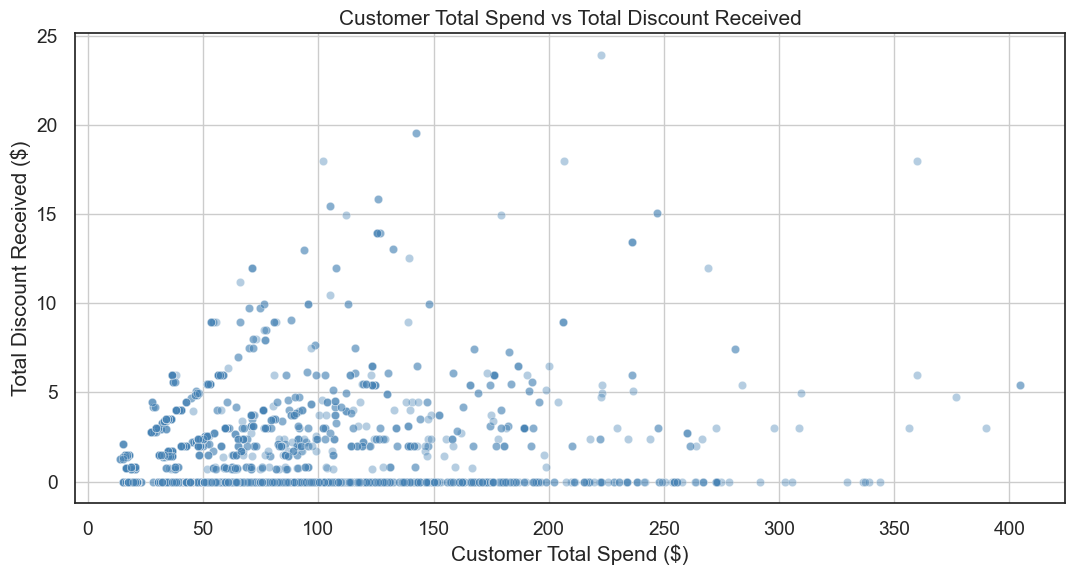

Correlation between total spend and total discount: 0.271
(1.0 = perfect positive relationship, 0 = no relationship)


In [180]:
#CODE CELL 11 — Scatter plot: spend vs discount amount
# Scatter plot: total spend vs total discount received per customer
# This shows visually whether high spenders are getting more discounts
plt.figure(figsize=(11, 6))
sns.scatterplot(data=summary,
                x='customer_total_spent',
                y='total_discount',
                alpha=0.4,
                color='steelblue')

plt.title('Customer Total Spend vs Total Discount Received')
plt.xlabel('Customer Total Spend ($)')
plt.ylabel('Total Discount Received ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Correlation between spend and discount
corr = summary[['customer_total_spent', 'total_discount']].corr().iloc[0,1]
print(f"Correlation between total spend and total discount: {corr:.3f}")
print("(1.0 = perfect positive relationship, 0 = no relationship)")

## 2.7 Do Discounts Drive Customer Retention?

The business brief identifies customer retention as a key challenge.
This analysis examines whether customers who received a discount on
their first order are more likely to return for a second purchase —
a direct test of whether discounts are effective as a retention tool.

In [181]:
#CODE CELL 12 — Repeat purchase rate by first order discount
# Find each customer's first order and whether it had a discount
first_orders = (orders.sort_values('order_date')
                      .groupby('customer_email')
                      .first()
                      .reset_index()
               [['customer_email', 'order_date', 'discount_flag', 'order_total']])

first_orders.rename(columns={
    'discount_flag': 'first_order_discounted',
    'order_date':    'first_order_date',
    'order_total':   'first_order_value'
}, inplace=True)

# Count total orders per customer
order_counts = (orders.groupby('customer_email')['order_id']
                      .count()
                      .reset_index()
                      .rename(columns={'order_id': 'total_orders'}))

# Merge and create repeat purchase flag
customer_df = first_orders.merge(order_counts, on='customer_email')
customer_df['is_repeat'] = (customer_df['total_orders'] > 1).astype(int)

# Compare repeat rates
repeat_rate = (customer_df.groupby('first_order_discounted')['is_repeat']
                          .mean() * 100).round(1)
repeat_rate.index = ['No Discount\non First Order',
                     'Discounted\nFirst Order']

print("=== REPEAT PURCHASE RATE BY FIRST ORDER DISCOUNT STATUS ===")
for idx, val in repeat_rate.items():
    print(f"  {idx.replace(chr(10), ' ')}: {val}%")

print(f"\nDifference: {repeat_rate.iloc[1] - repeat_rate.iloc[0]:.1f} percentage points")

# Overall retention stats
print(f"\nOverall customer retention rate: {customer_df['is_repeat'].mean()*100:.1f}%")
print(f"Single-purchase customers: {(customer_df['total_orders']==1).sum():,} ({(customer_df['total_orders']==1).mean()*100:.1f}%)")
print(f"Repeat customers:          {(customer_df['total_orders']>1).sum():,} ({(customer_df['total_orders']>1).mean()*100:.1f}%)")


=== REPEAT PURCHASE RATE BY FIRST ORDER DISCOUNT STATUS ===
  No Discount on First Order: 10.0%
  Discounted First Order: 9.8%

Difference: -0.2 percentage points

Overall customer retention rate: 10.0%
Single-purchase customers: 6,174 (90.0%)
Repeat customers:          685 (10.0%)


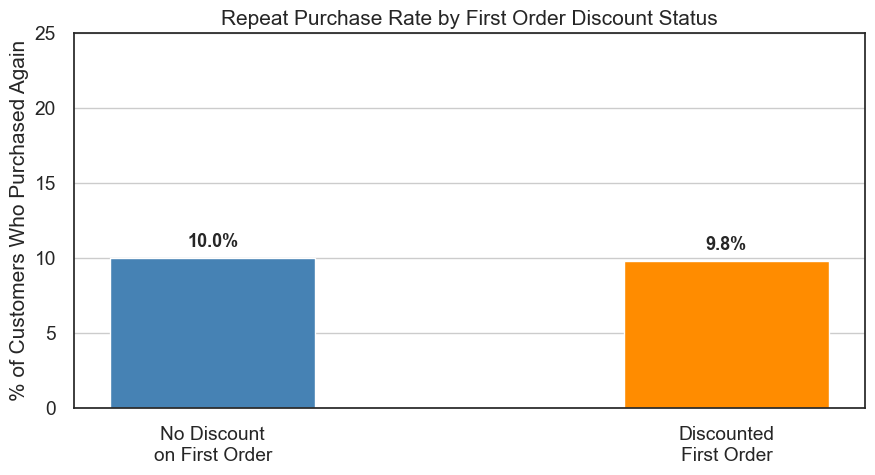

In [182]:
# Bar chart: repeat purchase rate by first order discount status
plt.figure(figsize=(9, 5))
colours = ['steelblue', 'darkorange']
bars = plt.bar(repeat_rate.index, repeat_rate.values,
               color=colours, width=0.4)

for bar, val in zip(bars, repeat_rate.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val}%', ha='center', va='bottom',
             fontsize=13, fontweight='bold')

plt.title('Repeat Purchase Rate by First Order Discount Status')
plt.ylabel('% of Customers Who Purchased Again')
plt.ylim(0, max(repeat_rate.values) + 15)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


## 2.8 Does Discounting Generate More Revenue?

The final question in this section examines whether the overall
revenue generated from discounted customers justifies the cost
of the discount. We compare the lifetime value of discounted
customers versus non-discounted customers to determine whether
discounting is a net positive strategy for the business.

In [183]:
#CODE CELL 14 — Revenue comparison: discounted vs non-discounted customers
# Identify whether each customer ever used a discount
customer_disc_flag = (summary['discount_orders'] > 0).astype(int)
summary['ever_discounted'] = customer_disc_flag

# Compare lifetime value between the two groups
ltv_comparison = summary.groupby('ever_discounted').agg(
    customer_count  = ('customer_email', 'count'),
    avg_total_spent = ('customer_total_spent', 'mean'),
    avg_orders      = ('total_orders', 'mean'),
    avg_active_days = ('active_days', 'mean'),
    total_revenue   = ('customer_total_spent', 'sum')
).round(2)

ltv_comparison.index = ['Never Discounted', 'Ever Discounted']
print("=== CUSTOMER LIFETIME VALUE: DISCOUNTED vs NON-DISCOUNTED ===")
print(ltv_comparison.to_string())

# Revenue split
total_rev = summary['customer_total_spent'].sum()
disc_rev  = summary[summary['ever_discounted']==1]['customer_total_spent'].sum()
nodisc_rev= summary[summary['ever_discounted']==0]['customer_total_spent'].sum()

print(f"\nRevenue from discounted customers:     ${disc_rev:,.2f} ({disc_rev/total_rev*100:.1f}%)")
print(f"Revenue from non-discounted customers: ${nodisc_rev:,.2f} ({nodisc_rev/total_rev*100:.1f}%)")


=== CUSTOMER LIFETIME VALUE: DISCOUNTED vs NON-DISCOUNTED ===
                  customer_count  avg_total_spent  avg_orders  avg_active_days  total_revenue
Never Discounted            4758            50.24        1.09            28.62      239047.88
Ever Discounted             2101            59.20        1.17            38.16      124383.64

Revenue from discounted customers:     $124,383.64 (34.2%)
Revenue from non-discounted customers: $239,047.88 (65.8%)


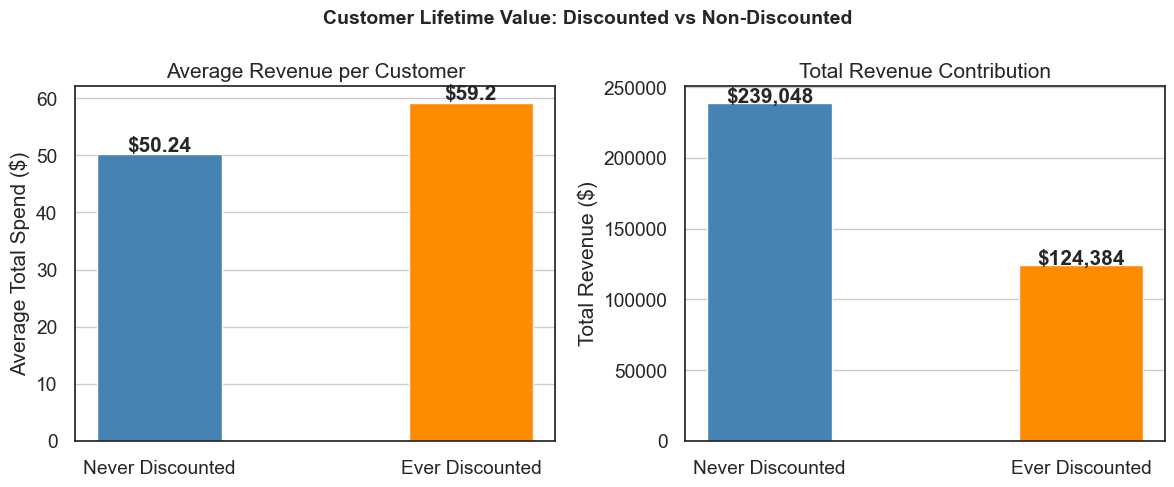

In [184]:
# Bar chart comparing lifetime value of discounted vs non-discounted customers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Average total spend per customer
groups = ['Never Discounted', 'Ever Discounted']
avg_spend = [50.24, 59.20]
colours = ['steelblue', 'darkorange']

axes[0].bar(groups, avg_spend, color=colours, width=0.4)
axes[0].set_title('Average Revenue per Customer')
axes[0].set_ylabel('Average Total Spend ($)')
for i, v in enumerate(avg_spend):
    axes[0].text(i, v + 0.5, f'${v}', ha='center', fontweight='bold')
axes[0].grid(True, axis='y')

# Chart 2: Total revenue contribution
total_rev = [239047.88, 124383.64]
axes[1].bar(groups, total_rev, color=colours, width=0.4)
axes[1].set_title('Total Revenue Contribution')
axes[1].set_ylabel('Total Revenue ($)')
for i, v in enumerate(total_rev):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')
axes[1].grid(True, axis='y')

plt.suptitle('Customer Lifetime Value: Discounted vs Non-Discounted',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.9 Discount Usage by Product Category

To understand whether discounts are being applied strategically
or broadly across the product range, we join the orderlines table
with the products table. This reveals which product categories
and ranges are most frequently discounted, and whether the
discount strategy is concentrated in specific areas such as
value packs or seasonal items.

In [185]:
# Join orderlines with products to get category information
# Then join with orders to get discount flag
orderlines_products = orderlines.merge(
    products[['product_id', 'range', 'type', 'category']],
    on='product_id',
    how='left'
)

orderlines_full = orderlines_products.merge(
    orders[['order_id', 'discount_flag', 'discount_amount']],
    on='order_id',
    how='left'
)

print(f"Joined table: {orderlines_full.shape[0]:,} rows")
orderlines_full.head()

Joined table: 87,669 rows


,order_id,product_id,variation_id,sku,line_id,qty_minus_refund,item_price,item_price_before_discount,range,type,category,discount_flag,discount_amount
0,ord_09520e04,prd_b33bcf92,NaN,NaN,1,1,37.77,39.75,Value pack,Crew Neck,"4 Pack,Build your pack",1,1.98
1,ord_09520e04,prd_21e303b3,var_bd909c41,NaN,2,1,0.00,0.00,Tops for Adam,Singlet,"Tops for Adams of 21st century, 1 Pack",1,1.98
2,ord_09520e04,prd_21e303b3,var_bd909c41,NaN,2,1,0.00,0.00,Tops for Adam,Singlet,"Tops for Adams of 21st century, 1 Pack",1,1.98
3,ord_09520e04,prd_21e303b3,var_bd909c41,NaN,2,1,0.00,0.00,Tops for Adam,Singlet,"Tops for Adams of 21st century, 1 Pack",1,1.98
4,ord_09520e04,prd_21e303b3,var_bd909c41,NaN,2,1,0.00,0.00,Tops for Adam,Singlet,"Tops for Adams of 21st century, 1 Pack",1,1.98


In [186]:
# Calculate discount rate by product range
range_disc = orderlines_full.groupby('range').agg(
    total_items   = ('qty_minus_refund', 'sum'),
    total_orders  = ('order_id', 'nunique'),
    disc_orders   = ('discount_flag', 'sum'),
    avg_item_price= ('item_price', 'mean')
).reset_index()

range_disc['disc_rate_pct'] = (range_disc['disc_orders'] /
                                range_disc['total_orders'] * 100).round(1)

# Sort by discount rate and show top 15
range_disc = range_disc.sort_values('disc_rate_pct', ascending=False)

print("=== DISCOUNT RATE BY PRODUCT RANGE (Top 15) ===")
print(range_disc.head(15).to_string(index=False))

=== DISCOUNT RATE BY PRODUCT RANGE (Top 15) ===
        range  total_items  total_orders  disc_orders  avg_item_price  disc_rate_pct
Tops for Adam        87970          6591        25355        7.786542          384.7
   Value pack        10306          3118         3406       43.321140          109.2


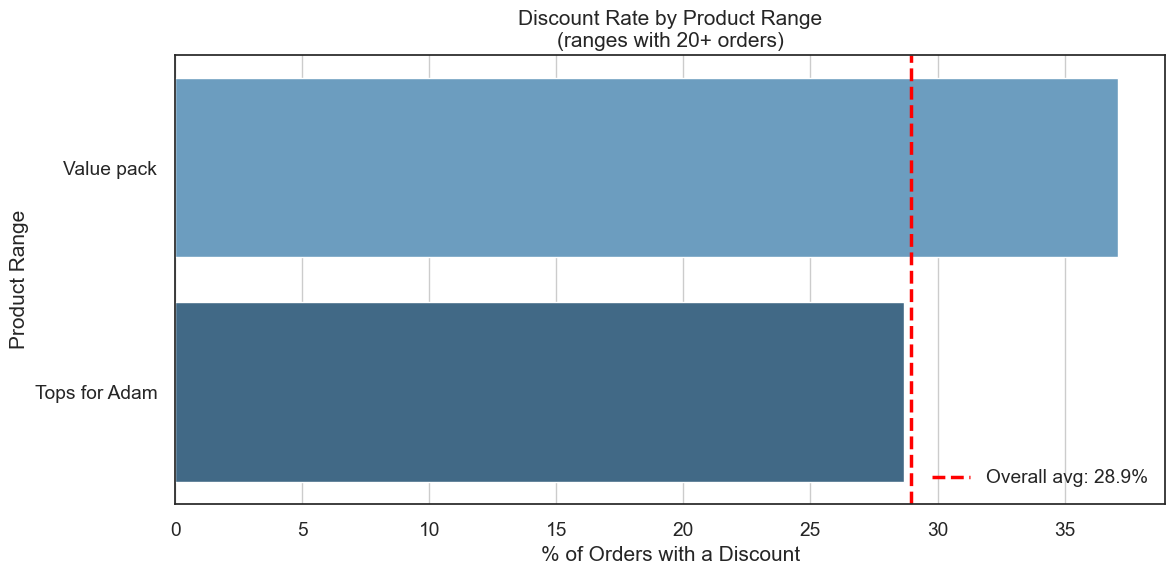

        range  total_orders  disc_rate_pct
   Value pack          3118           37.1
Tops for Adam          6591           28.7


In [187]:
# Fix: calculate discount rate correctly by unique orders per range
range_disc = orderlines_full.groupby('range').agg(
    total_orders = ('order_id', 'nunique'),
    disc_orders  = ('order_id', lambda x: orderlines_full.loc[x.index, 'discount_flag'].max())
).reset_index()

# Simpler approach - merge at order level first
order_range = orderlines_full[['order_id', 'range']].drop_duplicates()
order_range = order_range.merge(
    orders[['order_id', 'discount_flag']],
    on='order_id', how='left'
)

range_disc = order_range.groupby('range').agg(
    total_orders = ('order_id', 'nunique'),
    disc_orders  = ('discount_flag', 'sum')
).reset_index()

range_disc['disc_rate_pct'] = (range_disc['disc_orders'] /
                                range_disc['total_orders'] * 100).round(1)

range_filtered = range_disc[range_disc['total_orders'] >= 20].sort_values(
    'disc_rate_pct', ascending=False).head(12)

plt.figure(figsize=(12, 6))
sns.barplot(data=range_filtered, x='disc_rate_pct', y='range', palette='Blues_d')
plt.title('Discount Rate by Product Range\n(ranges with 20+ orders)')
plt.xlabel('% of Orders with a Discount')
plt.ylabel('Product Range')
plt.axvline(x=orders['discount_flag'].mean()*100, color='red', linestyle='--',
            label=f"Overall avg: {orders['discount_flag'].mean()*100:.1f}%")
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

print(range_filtered[['range', 'total_orders', 'disc_rate_pct']].to_string(index=False))


In [188]:
#CODE CELL 15 — Summary of all key findings for report
print("=== SECTION 2 — KEY FINDINGS SUMMARY FOR REPORT ===")

print(f"\n--- 2.2 Order Value Comparison ---")
print(f"  Avg order total (no discount): ${orders[orders['discount_flag']==0]['order_total'].mean():.2f}")
print(f"  Avg order total (discounted):  ${orders[orders['discount_flag']==1]['order_total'].mean():.2f}")
print(f"  Avg basket size (no discount): {basket_comparison.loc['No Discount', 'avg_items']} items")
print(f"  Avg basket size (discounted):  {basket_comparison.loc['Discounted', 'avg_items']} items")
print(f"  Basket size lift:              {lift:.1f}%")

print(f"\n--- 2.3 Discount Depth ---")
print(f"  Most common discount rate:     {discounted['discount_rate'].mode()[0]}%")
print(f"  Average discount rate:         {discounted['discount_rate'].mean():.1f}%")
print(f"  Orders under 10% discount:     {(discounted['discount_rate'] < 10).mean()*100:.1f}%")
print(f"  Orders 10-20% discount:        {((discounted['discount_rate'] >= 10) & (discounted['discount_rate'] <= 20)).mean()*100:.1f}%")
print(f"  Orders above 20% discount:     {(discounted['discount_rate'] > 20).mean()*100:.1f}%")

print(f"\n--- 2.4 Discount Frequency per Customer ---")
print(summary['discount_behaviour'].value_counts().to_string())

print(f"\n--- 2.5 Discount Dependency ---")
print(f"  Never used discount:           {(summary['discount_orders']==0).sum():,} ({(summary['discount_orders']==0).mean()*100:.1f}%)")
print(f"  Mixed behaviour:               {((summary['discount_orders']>0) & (summary['discount_dependent']==0)).sum():,} ({((summary['discount_orders']>0) & (summary['discount_dependent']==0)).mean()*100:.1f}%)")
print(f"  Discount dependent:            {summary['discount_dependent'].sum():,} ({summary['discount_dependent'].mean()*100:.1f}%)")

print(f"\n--- 2.6 Are Right Customers Getting Discounts? ---")
print(f"  Correlation (spend vs discount received): {summary[['customer_total_spent','total_discount']].corr().iloc[0,1]:.3f}")
print("  Discount usage rate by spend tier:")
print(spend_disc.to_string())

print(f"\n--- 2.7 Retention ---")
print(f"  Overall retention rate:          {customer_df['is_repeat'].mean()*100:.1f}%")
print(f"  Repeat rate (discounted first):  {repeat_rate.iloc[1]:.1f}%")
print(f"  Repeat rate (no discount first): {repeat_rate.iloc[0]:.1f}%")

print(f"\n--- 2.8 Revenue ---")
print(f"  Avg lifetime spend (discounted):     ${summary[summary['ever_discounted']==1]['customer_total_spent'].mean():.2f}")
print(f"  Avg lifetime spend (non-discounted): ${summary[summary['ever_discounted']==0]['customer_total_spent'].mean():.2f}")
print(f"  Revenue from discounted customers:   ${summary[summary['ever_discounted']==1]['customer_total_spent'].sum():,.2f} ({summary[summary['ever_discounted']==1]['customer_total_spent'].sum()/summary['customer_total_spent'].sum()*100:.1f}%)")
print(f"  Revenue from non-discounted:         ${summary[summary['ever_discounted']==0]['customer_total_spent'].sum():,.2f} ({summary[summary['ever_discounted']==0]['customer_total_spent'].sum()/summary['customer_total_spent'].sum()*100:.1f}%)")

print(f"\n--- 2.9 Product Category Discount Rates ---")
print(range_filtered[['range', 'total_orders', 'disc_rate_pct']].to_string(index=False))
print(f"  Overall average discount rate: {orders['discount_flag'].mean()*100:.1f}%")

=== SECTION 2 — KEY FINDINGS SUMMARY FOR REPORT ===

--- 2.2 Order Value Comparison ---
  Avg order total (no discount): $36.44
  Avg order total (discounted):  $39.12
  Avg basket size (no discount): 2.14 items
  Avg basket size (discounted):  2.74 items
  Basket size lift:              28.0%

--- 2.3 Discount Depth ---
  Most common discount rate:     4.99%
  Average discount rate:         6.7%
  Orders under 10% discount:     71.3%
  Orders 10-20% discount:        28.7%
  Orders above 20% discount:     0.0%

--- 2.4 Discount Frequency per Customer ---
discount_behaviour
Never used discount                 4758
Always uses discount (100%)         1873
Occasional discount user (1-50%)     220
Frequent discount user (51-99%)        8

--- 2.5 Discount Dependency ---
  Never used discount:           4,758 (69.4%)
  Mixed behaviour:               228 (3.3%)
  Discount dependent:            1,873 (27.3%)

--- 2.6 Are Right Customers Getting Discounts? ---
  Correlation (spend vs discount 

In [189]:
import pycaret
print(pycaret.__version__)


3.3.2


# Section 3 — Basic Predictive Modelling
 
## Business Question
**Can we predict which customers are at risk of not returning so the business knows exactly who to target with a retention
discount?**
 
Section 2 revealed that 90% of customers make only one purchase
and never return. Currently, discounts appear to be distributed
broadly without a clear targeting logic with a weak correlation
of 0.271 between customer spend and discounts received.
 
This model addresses that gap directly. Rather than giving
discounts to everyone, the business can use this model to
identify high-risk customers before they churn and deploy
retention discounts precisely where they are most needed.
Customers predicted as likely to return can be left to purchase
at full price protecting margin where it is not at risk.
 
This supports three of management core objectives:
- Improving customer retention to justify acquisition costs
- Optimising discount strategies to drive profitable behaviour
- Supporting more proactive, data-driven decision-making
 
### Modelling Approach
- **Model type:** Binary classification
- **Target variable:** `is_repeat` (1 = customer returned,
  0 = customer did not return)
- **Input features:** Customer and first-order characteristics
  available after the first purchase
- **Tool:** PyCaret classification module
- **Primary metric:** AUC — measures how well the model
  separates returning from non-returning customers
- **Secondary metrics:** Recall — prioritised because missing
  a churning customer (false negative) is more costly to the
  business than incorrectly flagging a loyal one

## 3.1 Data Preparation
 
The modelling dataset is built at the **customer level** —
one row per customer. Features describe what we know about
a customer after their first purchase, which is the realistic
point at which the business would decide whether to send a
retention discount.
 
Key variable decisions:
- **Included:** first order value, discount usage, basket size,
  shipping method, payment method, customer tenure
- **Excluded to prevent data leakage:** total_orders
  (directly determines the target), discount_rate on
  subsequent orders (not yet known after first purchase)

In [190]:
#CODE CELL 1 — Build customer-level modelling dataset
import pandas as pd
import numpy as np

# Step 1: Get each customer's FIRST order details
# These are the features known after first purchase
first_orders = (orders.sort_values('order_date')
                      .groupby('customer_email')
                      .first()
                      .reset_index()
               [['customer_email', 'order_date',
                 'discount_flag', 'order_total',
                 'order_subtotal', 'order_shipping',
                 'order_seq', 'shipping_method',
                 'payment_method']])
 
first_orders.rename(columns={
    'discount_flag':  'first_order_discounted',
    'order_date':     'first_order_date',
    'order_total':    'first_order_value',
    'order_subtotal': 'first_order_subtotal',
    'order_shipping': 'first_order_shipping',
    'order_seq':      'first_order_seq'
}, inplace=True)
 
# Step 2: Add basket size on first order
basket = (orderlines.groupby('order_id')
                    .agg(basket_size=('qty_minus_refund','sum'))
                    .reset_index())
 
# Get first order id per customer
first_order_ids = (orders.sort_values('order_date')
                         .groupby('customer_email')['order_id']
                         .first()
                         .reset_index()
                         .rename(columns={'order_id':'first_order_id'}))
 
first_orders = first_orders.merge(first_order_ids,
                                   on='customer_email', how='left')
first_orders = first_orders.merge(
    basket.rename(columns={'order_id':'first_order_id'}),
    on='first_order_id', how='left'
)
first_orders['basket_size'] = first_orders['basket_size'].fillna(1)
 
# Step 3: Count total orders per customer (to create target)
order_counts = (orders.groupby('customer_email')['order_id']
                      .count()
                      .reset_index()
                      .rename(columns={'order_id':'total_orders'}))
 
# Step 4: Merge everything
model_df = first_orders.merge(order_counts, on='customer_email')
 
# Step 5: Add customer tenure from customers table
model_df = model_df.merge(
    customers[['customer_email',
               'customer_first_order_date',
               'customer_last_order_date',
               'customer_total_spent']],
    on='customer_email', how='left'
)
 
model_df['active_days'] = (
    model_df['customer_last_order_date'] -
    model_df['customer_first_order_date']
).dt.days.fillna(0)
 
# Step 6: Create TARGET variable
# is_repeat = 1 if customer made more than one purchase
model_df['is_repeat'] = (model_df['total_orders'] > 1).astype(int)
 
print(f"Modelling dataset: {model_df.shape[0]:,} customers")
print(f"\nTarget distribution:")
print(f"  Will return (is_repeat=1): {model_df['is_repeat'].sum():,} ({model_df['is_repeat'].mean()*100:.1f}%)")
print(f"  Won't return (is_repeat=0): {(model_df['is_repeat']==0).sum():,} ({(model_df['is_repeat']==0).mean()*100:.1f}%)")
model_df.head()
 

Modelling dataset: 6,859 customers

Target distribution:
  Will return (is_repeat=1): 685 (10.0%)
  Won't return (is_repeat=0): 6,174 (90.0%)


,customer_email,first_order_date,first_order_discounted,first_order_value,first_order_subtotal,first_order_shipping,first_order_seq,shipping_method,payment_method,first_order_id,basket_size,total_orders,customer_first_order_date,customer_last_order_date,customer_total_spent,active_days,is_repeat
0,eml_00017309@gmail.example.net,2024-03-18,0,80.80,79.80,0.00,1,Courier (free),Cash on delivery,ord_370d09a6,8,2,2024-03-18,2024-03-29,161.60,11,1
1,eml_0005e884@gmail.example.net,2024-05-25,0,19.40,14.08,2.08,1,Pick-up Point,Online payment,ord_5de900f6,1,1,2024-05-25,2024-05-25,19.40,0,0
2,eml_0005f865@gmail.example.net,2024-04-22,0,99.40,98.40,0.00,1,Courier (free),Cash on delivery,ord_a592b9d7,4,1,2024-04-22,2024-04-22,99.40,0,0
3,eml_00079e62@gmail.example.net,2024-04-29,1,34.61,33.80,2.50,1,Pick-up Point,Cash on delivery,ord_80d62c1c,2,1,2024-04-29,2024-04-29,34.61,0,0
4,eml_000d251e@gmail.example.net,2024-03-05,0,17.40,14.90,2.50,1,Pick-up Point,Cash on delivery,ord_e16a6f3d,1,1,2024-03-05,2024-03-05,17.40,0,0


In [191]:
#CODE CELL 2 — Select final features
# Select only the features for modelling
# Removing ID columns, dates, and leakage variables
features = [
    'first_order_discounted',  # did first order have a discount?
    'first_order_value',       # how much did they spend first time?
    'first_order_subtotal',    # subtotal before discount
    'first_order_shipping',    # shipping cost on first order
    'first_order_seq',         # were they an early or late customer?
    'basket_size',             # how many items in first order?
    'shipping_method',         # shipping method chosen
    'payment_method',          # payment method used
    'customer_total_spent',    # total lifetime spend
    'active_days',             # days between first and last order
    'is_repeat'                # TARGET variable
]
 
model_data = model_df[features].copy()
 
# Handle any remaining missing values
model_data = model_data.dropna()
 
print(f"Final modelling dataset: {model_data.shape[0]:,} rows")
print(f"\nFeatures included: {model_data.shape[1]-1}")
print(f"\nMissing values: {model_data.isnull().sum().sum()}")
print(f"\nTarget distribution:")
print(model_data['is_repeat'].value_counts())
model_data.head()


Final modelling dataset: 6,859 rows

Features included: 10

Missing values: 0

Target distribution:
is_repeat
0    6174
1     685
Name: count, dtype: int64


,first_order_discounted,first_order_value,first_order_subtotal,first_order_shipping,first_order_seq,basket_size,shipping_method,payment_method,customer_total_spent,active_days,is_repeat
0,0,80.80,79.80,0.00,1,8,Courier (free),Cash on delivery,161.60,11,1
1,0,19.40,14.08,2.08,1,1,Pick-up Point,Online payment,19.40,0,0
2,0,99.40,98.40,0.00,1,4,Courier (free),Cash on delivery,99.40,0,0
3,1,34.61,33.80,2.50,1,2,Pick-up Point,Cash on delivery,34.61,0,0
4,0,17.40,14.90,2.50,1,1,Pick-up Point,Cash on delivery,17.40,0,0


## 3.2 Model Setup
 
PyCaret's classification module automates the full modelling
pipeline. Key configuration decisions:
 
- **Train/test split:** 70% training, 30% testing — the model
  is trained on 70% of customers and evaluated on the
  remaining 30% it has never seen
- **fix_imbalance = True:** the dataset has 90% non-returning
  and 10% returning customers — PyCaret uses SMOTE to
  synthetically balance the classes during training
- **normalize = True:** ensures all numeric features are on
  the same scale so no single variable dominates
- **session_id = 42:** fixes the random seed for
  reproducibility — running the model again produces
  identical results

In [192]:
#CODE CELL 3 — PyCaret setup
from pycaret.classification import *
 
clf = setup(
    data           = model_data,
    target         = 'is_repeat',
    session_id     = 42,
    fix_imbalance  = True,
    normalize      = True,
    train_size     = 0.7,
    verbose        = False
)
 
print("PyCaret setup complete!")
print(f"Training set: {get_config('X_train').shape[0]:,} customers")
print(f"Test set:     {get_config('X_test').shape[0]:,} customers")
print(f"Features:     {get_config('X_train').shape[1]}")

PyCaret setup complete!
Training set: 4,801 customers
Test set:     2,058 customers
Features:     10


## 3.3 Comparing Classification Models
 
Six models are trained and evaluated using 10-fold
cross-validation. Each fold trains on 90% of the training
data and validates on the remaining 10%, repeating 10 times
for a robust performance estimate.
 
Models compared:
- **lr** — Logistic Regression (interpretable baseline)
- **dt** — Decision Tree (visual and explainable)
- **rf** — Random Forest (typically strong performer)
- **ridge** — Ridge Classifier (regularised linear model)
- **ada** — AdaBoost (ensemble method)
- **lda** — Linear Discriminant Analysis
 
Models are ranked by **AUC**:
- AUC = 0.5 → no better than random guessing
- AUC = 0.7 → acceptable
- AUC = 0.8 → good
- AUC = 0.9 → excellent

In [193]:
#CODE CELL 4 — Compare models
best_models = compare_models(
    sort    = 'AUC',
    include = ['lr', 'dt', 'rf', 'ridge', 'ada', 'lda'],
    verbose = True
)
 
print("\nModel comparison complete!")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9790,0.9947,0.8643,0.9206,0.8909,0.8793,0.8802,0.1470
ada,Ada Boost Classifier,0.9392,0.9828,0.8957,0.6405,0.7462,0.7127,0.7262,0.1040
lr,Logistic Regression,0.9179,0.9423,0.8538,0.5586,0.6747,0.6302,0.6492,1.0260
dt,Decision Tree Classifier,0.9760,0.9375,0.8893,0.8734,0.8804,0.8671,0.8677,0.0470
ridge,Ridge Classifier,0.9152,0.9364,0.7786,0.5549,0.6471,0.6006,0.6123,0.0310
lda,Linear Discriminant Analysis,0.9150,0.9362,0.7766,0.5541,0.6459,0.5992,0.6108,0.0390



Model comparison complete!


## 3.4 Training the Best Model

Although Random Forest achieved a higher AUC of 0.9947, Logistic Regression was selected as the primary model for this preliminary analysis due to its interpretability. The difference in AUC of 0.052 is noted, and Random Forest can be used as the next step in Assessment 3 where model performance can be explored in greater depth.
 
We select **Logistic Regression** as our primary model for
two reasons:
 
1. **Interpretability** — it produces clear feature
   coefficients that directly explain which variables most
   strongly predict whether a customer will return. This
   transparency is essential for business decision-making.
 
2. **Appropriate complexity** — for a preliminary analysis
   with a dataset of this size, a simpler interpretable model
   is preferable to a black-box approach that cannot be
   explained to management.
 
If the model comparison above shows another model performing
significantly better (AUC difference > 0.05), that model will
be noted as a recommended next step for Assessment 3.

In [194]:
#CODE CELL 5 — Train Logistic Regression
# Train Logistic Regression model
lr_model = create_model('lr', verbose=False)
print("Model trained successfully!")

Model trained successfully!


In [195]:
#CODE CELL 6 — Evaluate on test set
# Evaluate on the held-out test set
print("=== MODEL PERFORMANCE ON UNSEEN TEST SET ===")
test_preds = predict_model(lr_model)
 
# Extract and print key metrics
from pycaret.classification import pull
metrics = pull()
 
print("\n=== KEY PERFORMANCE METRICS ===")
print(f"AUC:       {metrics['AUC'].values[0]:.3f}")
print(f"Accuracy:  {metrics['Accuracy'].values[0]:.3f}")
print(f"Recall:    {metrics['Recall'].values[0]:.3f}")
print(f"Precision: {metrics['Prec.'].values[0]:.3f}")
print(f"F1 Score:  {metrics['F1'].values[0]:.3f}")
 
print("\n=== BUSINESS INTERPRETATION OF METRICS ===")
print(f"AUC of {metrics['AUC'].values[0]:.3f} means the model correctly")
print(f"ranks a returning customer above a non-returning customer")
print(f"{metrics['AUC'].values[0]*100:.1f}% of the time")
 

=== MODEL PERFORMANCE ON UNSEEN TEST SET ===


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9203,0.9472,0.8786,0.5656,0.6882,0.6450,0.6656



=== KEY PERFORMANCE METRICS ===
AUC:       0.947
Accuracy:  0.920
Recall:    0.879
Precision: 0.566
F1 Score:  0.688

=== BUSINESS INTERPRETATION OF METRICS ===
AUC of 0.947 means the model correctly
ranks a returning customer above a non-returning customer
94.7% of the time


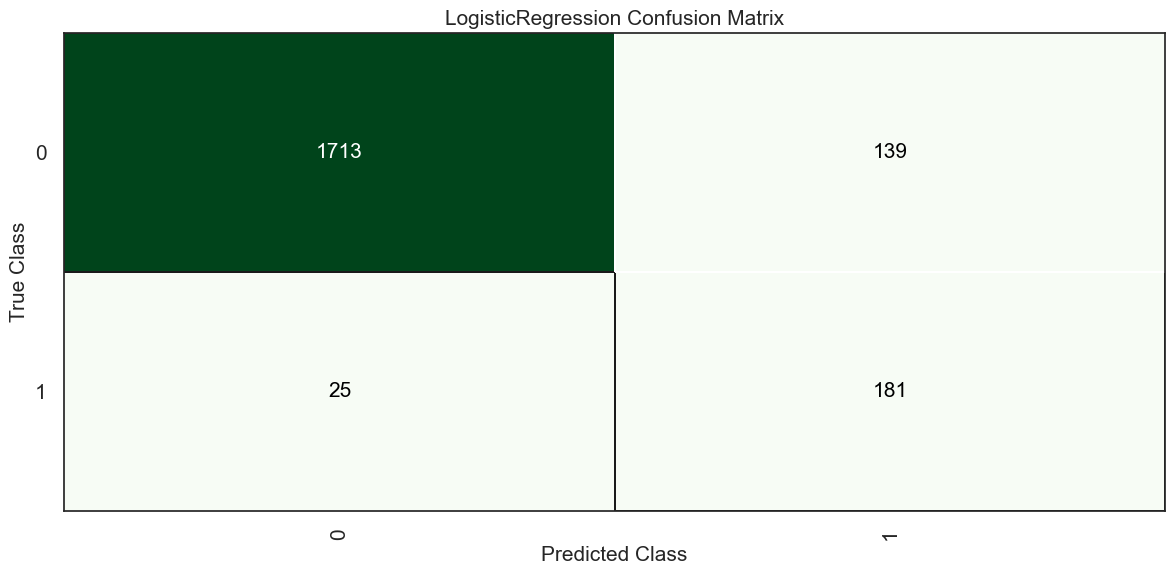

In [196]:
#CODE CELL 7 — Confusion Matrix
# Confusion matrix
# Top-left:  True Negatives  — correctly predicted non-returners
# Top-right: False Positives — predicted return, actually didn't
# Bottom-left: False Negatives — predicted no return, actually did
# Bottom-right: True Positives — correctly predicted returners
plot_model(lr_model, plot='confusion_matrix', verbose=False)
 

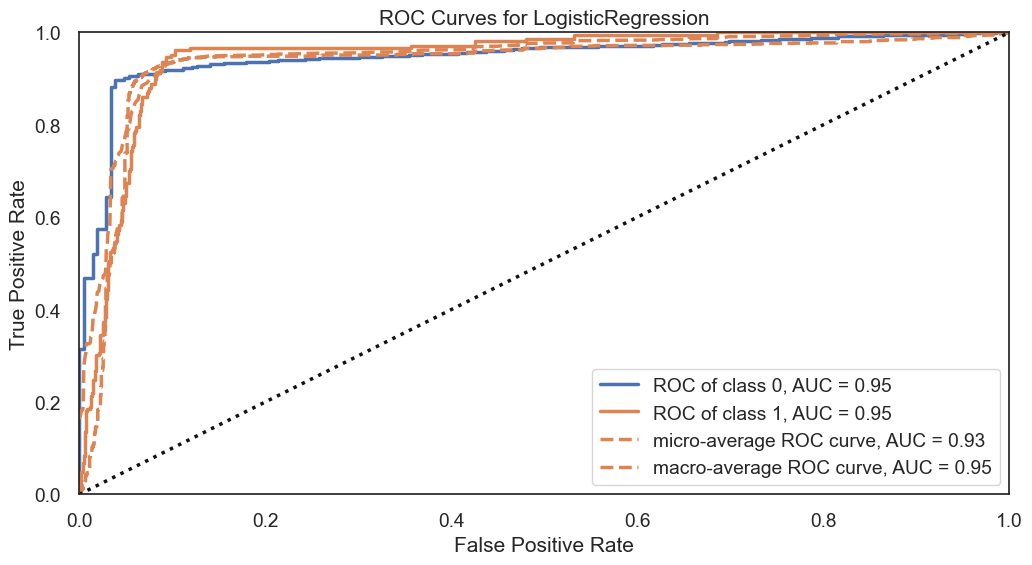

In [197]:
#CODE CELL 8 — ROC Curve
# ROC curve — visual of model discriminatory ability
# Diagonal line = random guessing (AUC = 0.5)
# Curve bowing toward top-left = better model
plot_model(lr_model, plot='auc', verbose=False)

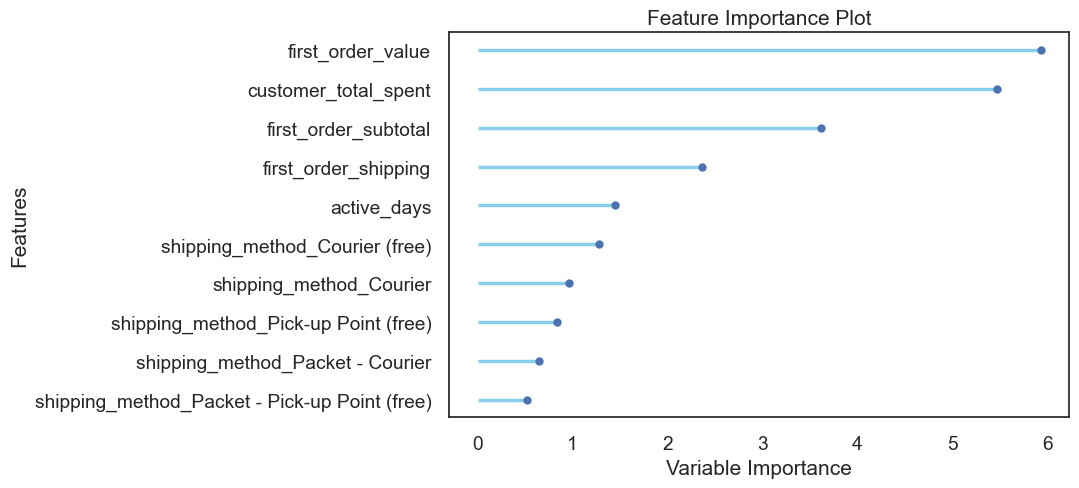

In [198]:
#CODE CELL 9 — Feature Importance
# Feature importance — THE KEY BUSINESS OUTPUT
# Which variables most strongly predict whether a customer
# will return?
# This directly answers: what should the business focus on
# to improve retention?
plot_model(lr_model, plot='feature', verbose=False)


In [199]:
# Apply the model to identify high-risk customers
# (those predicted as unlikely to return)
# These are the customers who should receive retention discounts
 
# Get predictions for all customers
all_predictions = predict_model(lr_model,
                                data=model_data.drop('is_repeat',
                                                     axis=1))
 
# Add back customer emails
all_predictions['customer_email'] = model_df['customer_email'].values[:len(all_predictions)]
 
# Identify high-risk customers (predicted not to return)
high_risk = all_predictions[
    all_predictions['prediction_label'] == 0
][['customer_email', 'prediction_score',
   'first_order_value', 'first_order_discounted']].copy()
 
high_risk = high_risk.sort_values('prediction_score',
                                   ascending=True)
 
print(f"=== HIGH-RISK CUSTOMERS IDENTIFIED ===")
print(f"Total customers analysed: {len(all_predictions):,}")
print(f"Predicted not to return:  {len(high_risk):,} ({len(high_risk)/len(all_predictions)*100:.1f}%)")
print(f"Predicted to return:      {(all_predictions['prediction_label']==1).sum():,}")
print(f"\nTop 10 highest-risk customers to target:")
print(high_risk.head(10).to_string(index=False))


=== HIGH-RISK CUSTOMERS IDENTIFIED ===
Total customers analysed: 6,859
Predicted not to return:  5,801 (84.6%)
Predicted to return:      1,058

Top 10 highest-risk customers to target:
                customer_email  prediction_score  first_order_value  first_order_discounted
eml_c144f0a3@gmail.example.net            0.5014          16.660000                       1
eml_af2f461c@gmail.example.net            0.5020          47.820000                       1
eml_111865fd@gmail.example.net            0.5132          32.110001                       1
eml_d5008d69@gmail.example.net            0.5132          32.110001                       1
eml_d8abf728@gmail.example.net            0.5132          32.110001                       1
eml_6b7ff068@gmail.example.net            0.5132          32.110001                       1
eml_a7736ac8@gmail.example.net            0.5134          47.820000                       1
eml_01d16591@gmail.example.net            0.5134          47.820000            